In [3]:
import pandas as pd

# 1. Read the CSV file
df = pd.read_csv('C2022_A/c2022_a_rv.csv')

# 2. View the first 5 rows (the head)
print(df.head())

# 3. View just the column header names
print(df.columns.tolist())

   UNITID  CIPCODE  MAJORNUM  AWLEVEL XCTOTALT  CTOTALT XCTOTALM  CTOTALM  \
0  100654   1.0999         1        5        R        9        R        3   
1  100654   1.1001         1        5        R        7        R        3   
2  100654   1.1001         1        7        R        7        R        1   
3  100654   1.1001         1       17        R        3        R        1   
4  100654   1.9999         1        5        R        1        R        1   

  XCTOTALW  CTOTALW  ... XCUNKNM  CUNKNM XCUNKNW  CUNKNW XCNRALT  CNRALT  \
0        R        6  ...       Z       0       Z       0       Z       0   
1        R        4  ...       Z       0       Z       0       Z       0   
2        R        6  ...       Z       0       R       2       R       2   
3        R        2  ...       Z       0       Z       0       Z       0   
4        Z        0  ...       Z       0       Z       0       Z       0   

  XCNRALM  CNRALM XCNRALW  CNRALW    
0       Z       0       Z         0  
1   

In [5]:
import pandas as pd

df = pd.read_csv("C2022_A/c2022_a_rv.csv", dtype={"CIPCODE": str})

print(df.head())
print(df.columns)

   UNITID  CIPCODE  MAJORNUM  AWLEVEL XCTOTALT  CTOTALT XCTOTALM  CTOTALM  \
0  100654  01.0999         1        5        R        9        R        3   
1  100654  01.1001         1        5        R        7        R        3   
2  100654  01.1001         1        7        R        7        R        1   
3  100654  01.1001         1       17        R        3        R        1   
4  100654  01.9999         1        5        R        1        R        1   

  XCTOTALW  CTOTALW  ... XCUNKNM  CUNKNM XCUNKNW  CUNKNW XCNRALT  CNRALT  \
0        R        6  ...       Z       0       Z       0       Z       0   
1        R        4  ...       Z       0       Z       0       Z       0   
2        R        6  ...       Z       0       R       2       R       2   
3        R        2  ...       Z       0       Z       0       Z       0   
4        Z        0  ...       Z       0       Z       0       Z       0   

  XCNRALM  CNRALM XCNRALW  CNRALW    
0       Z       0       Z         0  
1   

In [7]:
degree_map = {
    3: "Associate",
    5: "Bachelor",
    7: "Master",
    17: "PhD / Doctor Research"
}

df2 = df[df["AWLEVEL"].isin(degree_map.keys())].copy()
df2["degree_level"] = df2["AWLEVEL"].map(degree_map)

summary = (
    df2.groupby(["degree_level", "CIPCODE"], as_index=False)["CTOTALT"]
    .sum()
    .sort_values(["degree_level", "CTOTALT"], ascending=[True, False])
)

print(summary.head(5))

     degree_level  CIPCODE  CTOTALT
1030    Associate       99  1016944
423     Associate  24.0101   249611
424     Associate  24.0102    96531
927     Associate  51.3801    82018
942     Associate  52.0201    58693


In [9]:
import pandas as pd

df = pd.read_csv("C2022_A/c2022_a_rv.csv", dtype={"CIPCODE": str})

degree_map = {
    3: "Associate",
    5: "Bachelor",
    7: "Master",
    17: "PhD / Doctor Research"
}

df["AWLEVEL"] = pd.to_numeric(df["AWLEVEL"], errors="coerce")
df["CTOTALT"] = pd.to_numeric(df["CTOTALT"], errors="coerce").fillna(0)

# Keep only AS, BS, MS, PhD
df2 = df[df["AWLEVEL"].isin(degree_map.keys())].copy()

# Remove total/summary major code
df2 = df2[df2["CIPCODE"] != "99"]

df2["year"] = 2022
df2["degree_level"] = df2["AWLEVEL"].map(degree_map)

summary = (
    df2.groupby(["year", "degree_level", "CIPCODE"], as_index=False)["CTOTALT"]
    .sum()
    .rename(columns={
        "CIPCODE": "major_code",
        "CTOTALT": "degree_count"
    })
)

print(summary.head(5).to_string(index=False))

 year degree_level major_code  degree_count
 2022    Associate    01.0000           812
 2022    Associate    01.0101           577
 2022    Associate    01.0102           725
 2022    Associate    01.0103            23
 2022    Associate    01.0104            97


In [13]:
import pandas as pd

# Your IPEDS completions file
df = pd.read_csv("C2022_A/c2022_a_rv.csv", dtype={"CIPCODE": str})

# Downloaded CIP name file from NCES
cip = pd.read_csv("CIPCode2020.csv", dtype=str)

print(cip.columns)

Index(['CIPFamily', 'CIPCode', 'Action', 'TextChange', 'CIPTitle',
       'CIPDefinition', 'CrossReferences', 'Examples'],
      dtype='object')


In [25]:
import pandas as pd
import re

df = pd.read_csv("C2022_A/c2022_a_rv.csv", dtype={"CIPCODE": str})
cip = pd.read_csv("CIPCode2020.csv", dtype=str)

def clean_cip(code):
    if pd.isna(code):
        return None
    
    code = str(code).strip()
    
    # keep only numbers
    digits = re.sub(r"[^0-9]", "", code)
    
    # convert 240101 -> 24.0101
    if len(digits) == 6:
        return digits[:2] + "." + digits[2:]
    
    return None

# Clean IPEDS major code
df["major_code"] = df["CIPCODE"].apply(clean_cip)

# Clean CIP lookup major code
cip["major_code"] = cip["CIPCode"].apply(clean_cip)

cip_lookup = cip[["major_code", "CIPTitle"]].copy()
cip_lookup = cip_lookup.rename(columns={"CIPTitle": "major_name"})

# Remove bad rows
cip_lookup = cip_lookup.dropna(subset=["major_code"])
cip_lookup = cip_lookup.drop_duplicates(subset=["major_code"])

# write and download see the file that are clean:

In [31]:
#write the file name for summary of clean and print next file 
# Save the cleaned degree-level/major summary as a CSV file
summary.to_csv("IPEDS_2022_degree_level_major_name.csv", index=False)

In [35]:
#this is for print
degree_map = {
    3: "Associate",
    5: "Bachelor",
    7: "Master",
    17: "PhD / Doctor Research"
}

df["AWLEVEL"] = pd.to_numeric(df["AWLEVEL"], errors="coerce")
df["CTOTALT"] = pd.to_numeric(df["CTOTALT"], errors="coerce").fillna(0)

# Keep only AS, BS, MS, PhD
df2 = df[df["AWLEVEL"].isin(degree_map.keys())].copy()

# Keep only real major codes like 24.0101, 11.0101, 14.1001
df2 = df2[df2["CIPCODE"].str.match(r"^\d{2}\.\d{4}$", na=False)]

df2["year"] = 2022
df2["degree_level"] = df2["AWLEVEL"].map(degree_map)

summary = (
    df2.groupby(["year", "degree_level", "CIPCODE"], as_index=False)["CTOTALT"]
    .sum()
    .rename(columns={
        "CIPCODE": "major_code",
        "CTOTALT": "degree_count"
    })
)

# Add major name
summary = summary.merge(cip_lookup, on="major_code", how="left")

# Final clean table
summary = summary[[
    "year",
    "degree_level",
    "major_code",
    "major_name",
    "degree_count"
]]

summary = summary.sort_values(
    ["degree_level", "degree_count"],
    ascending=[True, False]
)

print(summary.head(5).to_string(index=False))

 year degree_level major_code                                       major_name  degree_count
 2022    Associate    24.0101       Liberal Arts and Sciences/Liberal Studies.        249611
 2022    Associate    24.0102                                 General Studies.         96531
 2022    Associate    51.3801             Registered Nursing/Registered Nurse.         82018
 2022    Associate    52.0201 Business Administration and Management, General.         58693
 2022    Associate    30.0101                Biological and Physical Sciences.         25622


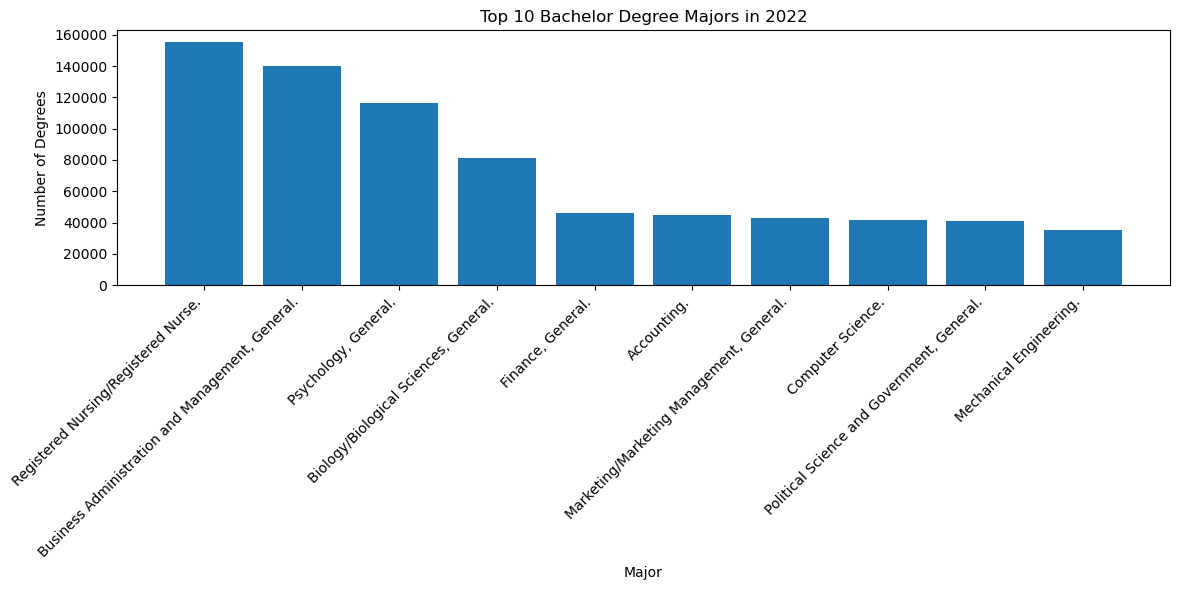

In [39]:
import matplotlib.pyplot as plt

# Pick only Bachelor degree
bachelor = summary[summary["degree_level"] == "Bachelor"]

# Sort and keep top 10 majors
top10 = bachelor.sort_values("degree_count", ascending=False).head(10)

# Make bar chart
plt.figure(figsize=(12, 6))
plt.bar(top10["major_name"], top10["degree_count"])

plt.title("Top 10 Bachelor Degree Majors in 2022")
plt.xlabel("Major")
plt.ylabel("Number of Degrees")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

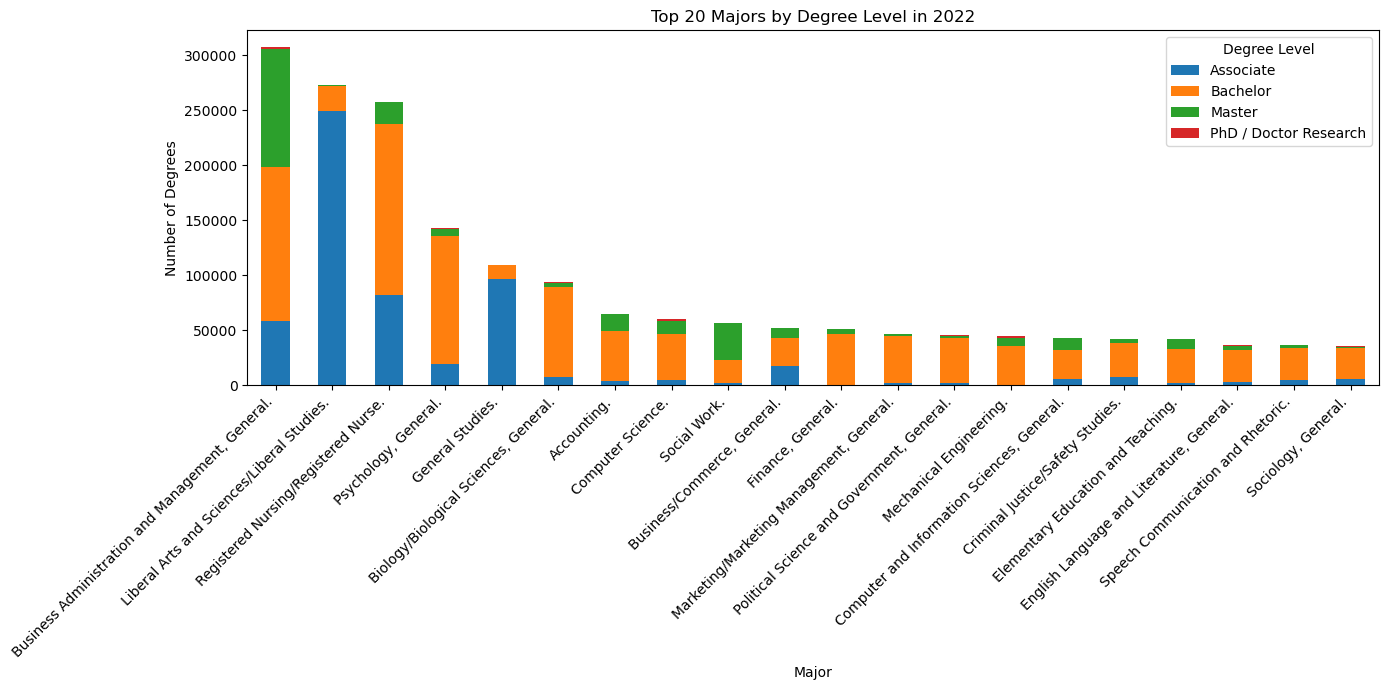

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure degree_count is numeric
summary["degree_count"] = pd.to_numeric(summary["degree_count"], errors="coerce").fillna(0)

# Find top 20 majors by total degrees
top_majors = (
    summary.groupby("major_name")["degree_count"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .index
)

# Keep only top 20 majors
top_summary = summary[summary["major_name"].isin(top_majors)]

# Pivot table for stacked bar
pivot = top_summary.pivot_table(
    index="major_name",
    columns="degree_level",
    values="degree_count",
    aggfunc="sum",
    fill_value=0
)

# Sort by total degrees
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

# Plot stacked bar
pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title("Top 20 Majors by Degree Level in 2022")
plt.xlabel("Major")
plt.ylabel("Number of Degrees")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Degree Level")
plt.tight_layout()
plt.show()

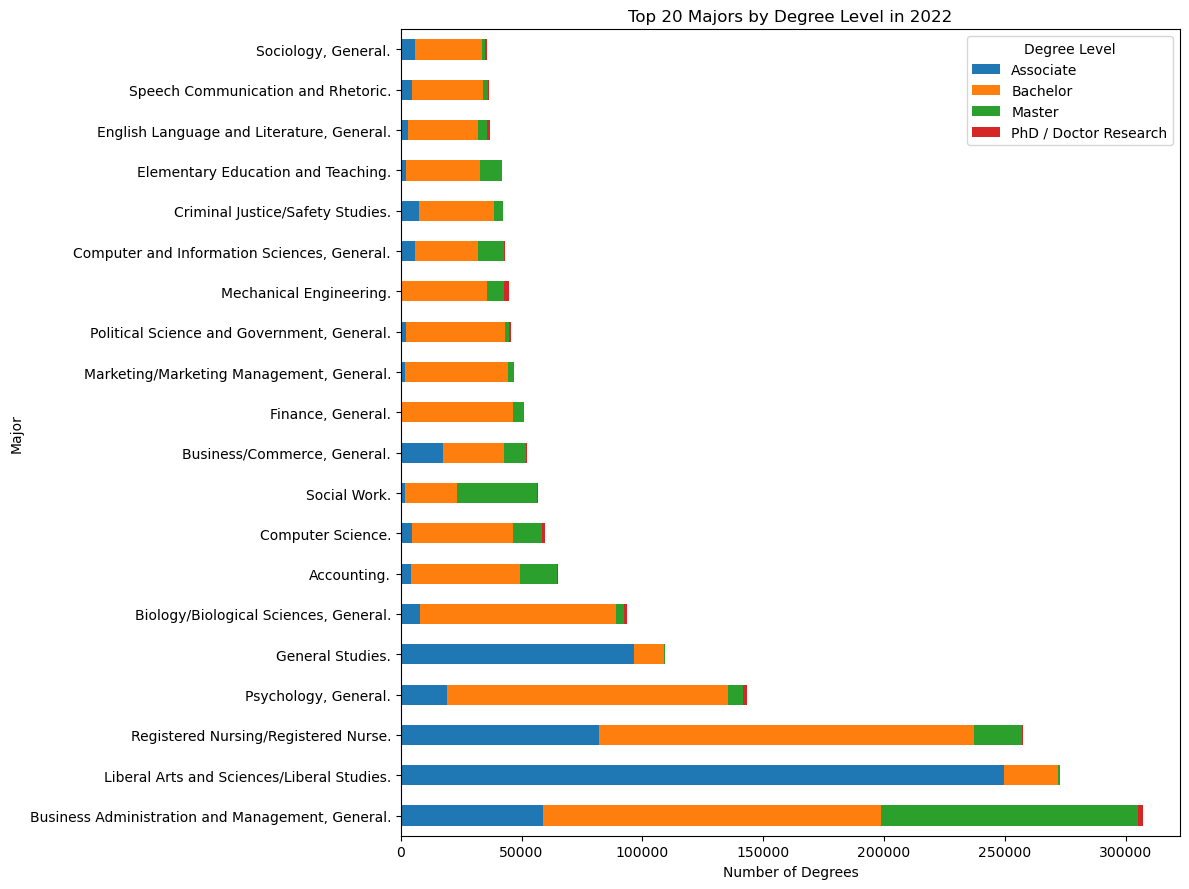

In [43]:
pivot.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 9)
)

plt.title("Top 20 Majors by Degree Level in 2022")
plt.xlabel("Number of Degrees")
plt.ylabel("Major")
plt.legend(title="Degree Level")
plt.tight_layout()
plt.show()

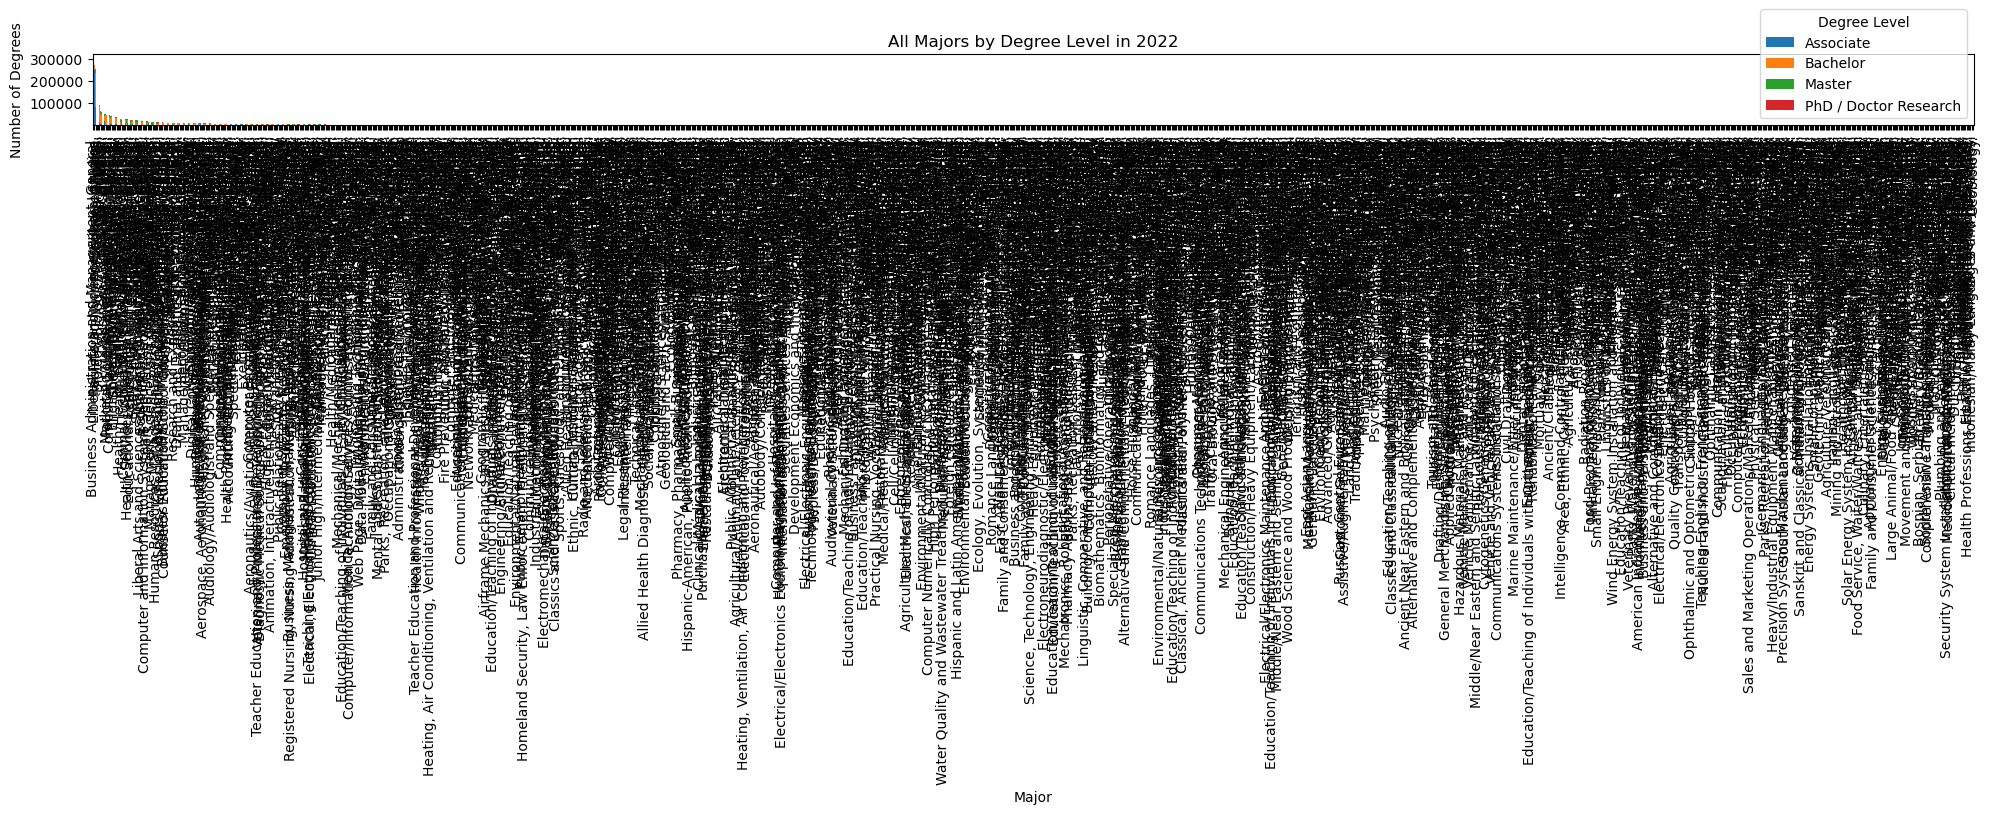

In [46]:
pivot_all = summary.pivot_table(
    index="major_name",
    columns="degree_level",
    values="degree_count",
    aggfunc="sum",
    fill_value=0
)

pivot_all = pivot_all.loc[pivot_all.sum(axis=1).sort_values(ascending=False).index]

pivot_all.plot(
    kind="bar",
    stacked=True,
    figsize=(20, 8)
)

plt.title("All Majors by Degree Level in 2022")
plt.xlabel("Major")
plt.ylabel("Number of Degrees")
plt.xticks(rotation=90)
plt.legend(title="Degree Level")
plt.tight_layout()
plt.show()

In [52]:
final_dataset = summary.copy()

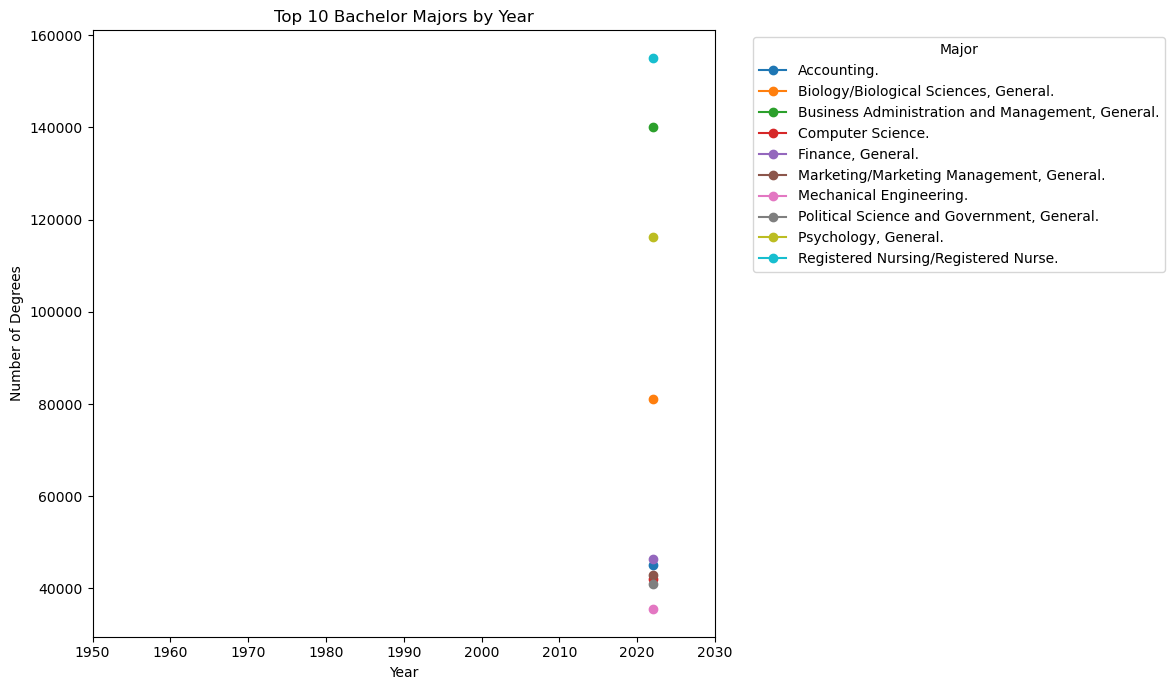

In [66]:
# Create a line chart showing how degree counts change by year for each major
# Plot degree count trends by year and major

import matplotlib.pyplot as plt
import pandas as pd

final_dataset["year"] = pd.to_numeric(final_dataset["year"], errors="coerce")
final_dataset["degree_count"] = pd.to_numeric(final_dataset["degree_count"], errors="coerce")

degree = "Bachelor"

df_plot = final_dataset[final_dataset["degree_level"] == degree].copy()

top_majors = (
    df_plot.groupby("major_name")["degree_count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

df_plot = df_plot[df_plot["major_name"].isin(top_majors)]

pivot = df_plot.pivot_table(
    index="year",
    columns="major_name",
    values="degree_count",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(12, 7))

for major in pivot.columns:
    plt.plot(pivot.index, pivot[major], marker="o", label=major)

plt.title(f"Top 10 {degree} Majors by Year")
plt.xlabel("Year")
plt.ylabel("Number of Degrees")

# Fix year axis only from 2022 to 2026
#plt.xlim(1950, 2026)
#plt.xticks([2022, 2023, 2024, 2025, 2026])
#Fix year 1950-2030
plt.xlim(1950, 2030)

plt.legend(title="Major", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

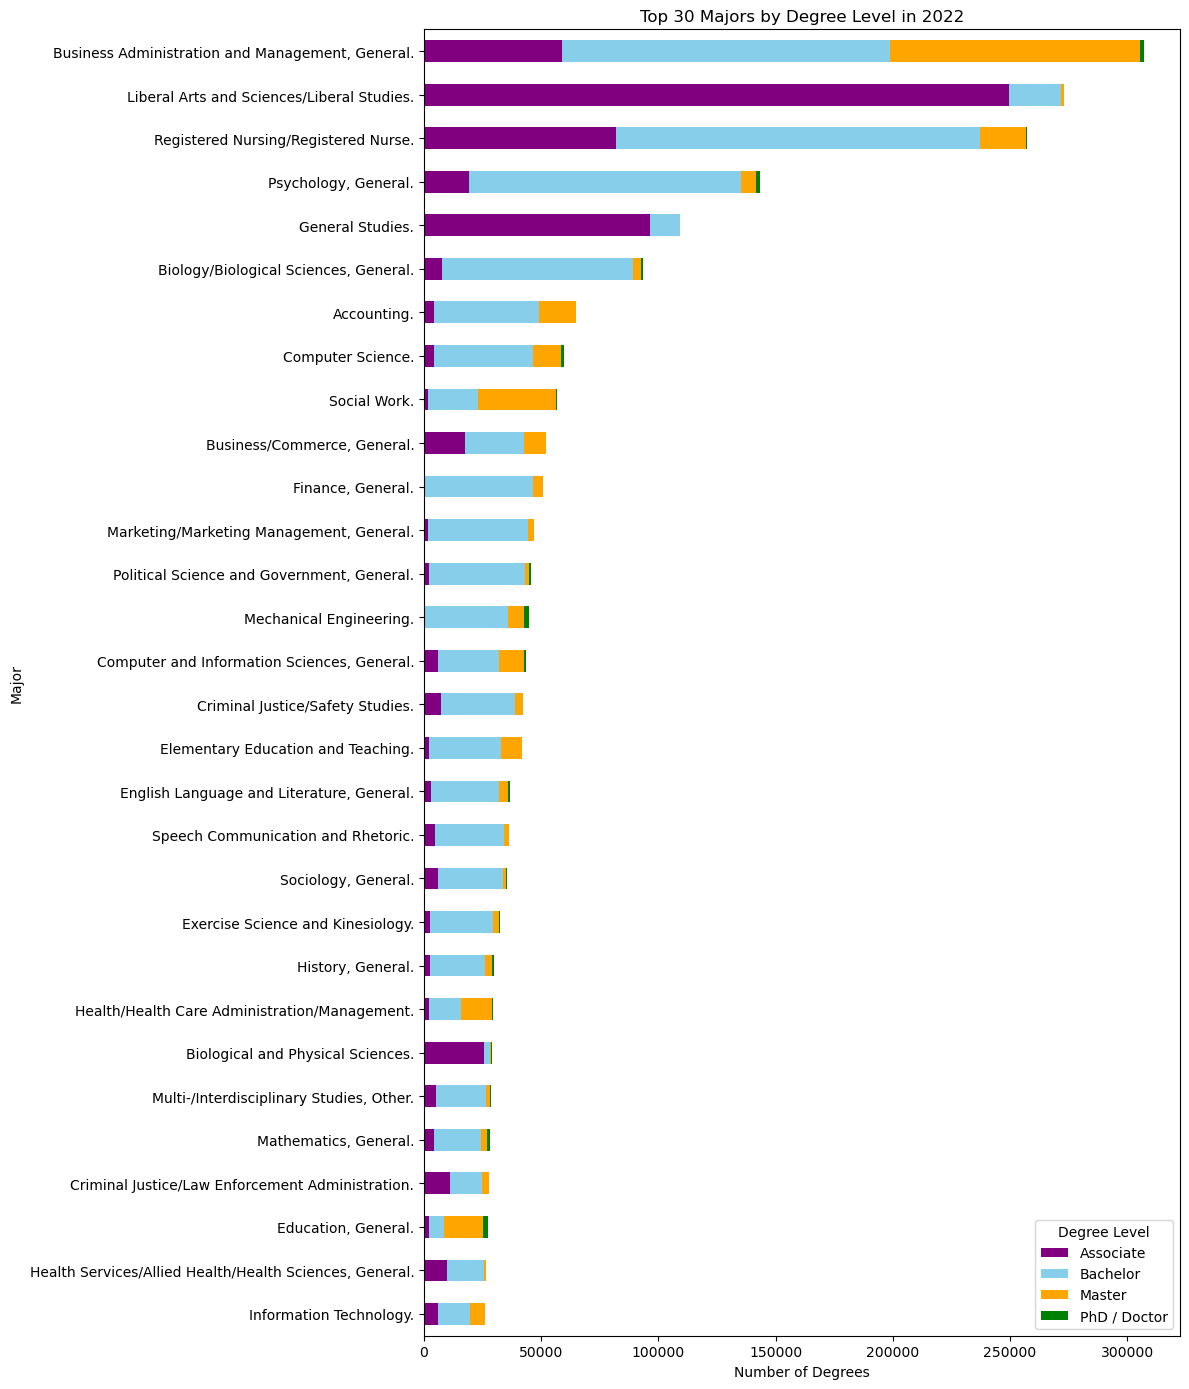

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

# Clean numeric columns
final_dataset["year"] = pd.to_numeric(final_dataset["year"], errors="coerce")
final_dataset["degree_count"] = pd.to_numeric(final_dataset["degree_count"], errors="coerce")

# Choose year and top number
year_choice = 2022
top_n = 30

# Filter by year only
df_plot = final_dataset[final_dataset["year"] == year_choice].copy()

# Make sure degree_level is text
df_plot["degree_level"] = df_plot["degree_level"].astype(str)

# Create degree group column
df_plot["degree_group"] = "Other"

df_plot.loc[
    df_plot["degree_level"].str.contains("Associate", case=False, na=False),
    "degree_group"
] = "Associate"

df_plot.loc[
    df_plot["degree_level"].str.contains("Bachelor", case=False, na=False),
    "degree_group"
] = "Bachelor"

df_plot.loc[
    df_plot["degree_level"].str.contains("Master", case=False, na=False),
    "degree_group"
] = "Master"

df_plot.loc[
    df_plot["degree_level"].str.contains("Doctor|PhD|Ph.D", case=False, na=False),
    "degree_group"
] = "PhD / Doctor"

df_plot.loc[
    df_plot["degree_level"].str.contains(
        "Post|Certificate|Graduate certificate|Postdoctoral",
        case=False,
        na=False
    ),
    "degree_group"
] = "Advanced / Certificate"

# Keep only the degree groups you want
df_plot = df_plot[
    df_plot["degree_group"].isin([
        "Associate",
        "Bachelor",
        "Master",
        "PhD / Doctor",
        "Advanced / Certificate"
    ])
]

# Get top majors
top_majors = (
    df_plot.groupby("major_name")["degree_count"]
    .sum()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

df_top = df_plot[df_plot["major_name"].isin(top_majors)]

# Create pivot table
pivot = df_top.pivot_table(
    index="major_name",
    columns="degree_group",
    values="degree_count",
    aggfunc="sum",
    fill_value=0
)

# Put degree levels in order
degree_order = [
    "Associate",
    "Bachelor",
    "Master",
    "PhD / Doctor",
    "Advanced / Certificate"
]

pivot = pivot[[col for col in degree_order if col in pivot.columns]]

# Sort so largest total appears at the top visually
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=True).index]

# Colors for each degree group
colors = {
    "Associate": "purple",
    "Bachelor": "skyblue",
    "Master": "orange",
    "PhD / Doctor": "green",
    "Advanced / Certificate": "red"
}

plot_colors = [colors[col] for col in pivot.columns]

# Plot stacked horizontal bar chart
pivot.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 14),
    color=plot_colors
)

plt.title(f"Top {top_n} Majors by Degree Level in {year_choice}")
plt.xlabel("Number of Degrees")
plt.ylabel("Major")
plt.legend(title="Degree Level")
plt.tight_layout()
plt.show()

In [93]:
import pandas as pd

# Clean numeric columns
final_dataset["year"] = pd.to_numeric(final_dataset["year"], errors="coerce")
final_dataset["degree_count"] = pd.to_numeric(final_dataset["degree_count"], errors="coerce")

# Choose year
year_choice = 2022

# Filter by year
df_plot = final_dataset[final_dataset["year"] == year_choice].copy()

# Make sure degree_level is text
df_plot["degree_level"] = df_plot["degree_level"].astype(str)

# Create degree group
df_plot["degree_group"] = "Other"

df_plot.loc[
    df_plot["degree_level"].str.contains("Associate", case=False, na=False),
    "degree_group"
] = "Associate"

df_plot.loc[
    df_plot["degree_level"].str.contains("Bachelor", case=False, na=False),
    "degree_group"
] = "Bachelor"

df_plot.loc[
    df_plot["degree_level"].str.contains("Master", case=False, na=False),
    "degree_group"
] = "Master"

df_plot.loc[
    df_plot["degree_level"].str.contains("Doctor|PhD|Ph.D", case=False, na=False),
    "degree_group"
] = "PhD / Doctor"

df_plot.loc[
    df_plot["degree_level"].str.contains(
        "Post|Certificate|Graduate certificate|Postdoctoral",
        case=False,
        na=False
    ),
    "degree_group"
] = "Advanced / Certificate"

# Keep only selected degree groups
df_plot = df_plot[
    df_plot["degree_group"].isin([
        "Associate",
        "Bachelor",
        "Master",
        "PhD / Doctor",
        "Advanced / Certificate"
    ])
]

# Print degree level and total number
degree_summary = (
    df_plot.groupby("degree_group")["degree_count"]
    .sum()
    .reset_index()
    .sort_values("degree_count", ascending=False)
)

print(degree_summary)

   degree_group  degree_count
1      Bachelor       2138714
0     Associate       1016944
2        Master        897284
3  PhD / Doctor         80555


In [108]:
import pandas as pd

# Clean numeric columns
final_dataset["year"] = pd.to_numeric(final_dataset["year"], errors="coerce")
final_dataset["degree_count"] = pd.to_numeric(final_dataset["degree_count"], errors="coerce")

# Choose year
year_choice = 2022

# Use None for all majors, or use a number like 30
top_n = None
# top_n = 30

# Filter by year
df_plot = final_dataset[final_dataset["year"] == year_choice].copy()

# Make sure degree_level is text
df_plot["degree_level"] = df_plot["degree_level"].astype(str)

# Create degree group
df_plot["degree_group"] = "Other"

df_plot.loc[
    df_plot["degree_level"].str.contains("Associate", case=False, na=False),
    "degree_group"
] = "Associate"

df_plot.loc[
    df_plot["degree_level"].str.contains("Bachelor", case=False, na=False),
    "degree_group"
] = "Bachelor"

df_plot.loc[
    df_plot["degree_level"].str.contains("Master", case=False, na=False),
    "degree_group"
] = "Master"

df_plot.loc[
    df_plot["degree_level"].str.contains("Doctor|PhD|Ph.D", case=False, na=False),
    "degree_group"
] = "PhD / Doctor"

df_plot.loc[
    df_plot["degree_level"].str.contains(
        "Post|Certificate|Graduate certificate|Postdoctoral",
        case=False,
        na=False
    ),
    "degree_group"
] = "Advanced / Certificate"

# Keep only selected degree groups
df_plot = df_plot[
    df_plot["degree_group"].isin([
        "Associate",
        "Bachelor",
        "Master",
        "PhD / Doctor",
        "Advanced / Certificate"
    ])
]

# Get major totals
major_totals = (
    df_plot.groupby("major_name")["degree_count"]
    .sum()
    .sort_values(ascending=False)
)

# Choose all majors or top N majors
if top_n is None:
    selected_majors = major_totals.index
else:
    selected_majors = major_totals.head(top_n).index

df_top = df_plot[df_plot["major_name"].isin(selected_majors)]

# Summary by major and degree
major_degree_summary = (
    df_top.groupby(["major_name", "degree_group"])["degree_count"]
    .sum()
    .reset_index()
    .sort_values(["major_name", "degree_count"], ascending=[True, False])
)

# Show all rows
pd.set_option("display.max_rows", None)

#print(major_degree_summary)

In [110]:
major_degree_table = major_degree_summary.pivot_table(
    index="major_name",
    columns="degree_group",
    values="degree_count",
    fill_value=0
)

#print(major_degree_table)

In [112]:
major_degree_summary = (
    df_top.groupby(["major_name", "degree_group"])["degree_count"]
    .sum()
    .reset_index()
    .sort_values(["major_name", "degree_group"])
)

# Print clean table without cutting columns
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 300)

#print(major_degree_summary.to_string(index=False))

# Field of study Shorter

In [102]:
import pandas as pd

# Clean numeric columns
final_dataset["year"] = pd.to_numeric(final_dataset["year"], errors="coerce")
final_dataset["degree_count"] = pd.to_numeric(final_dataset["degree_count"], errors="coerce")

# Choose year
year_choice = 2022

# Filter by year
df_plot = final_dataset[final_dataset["year"] == year_choice].copy()

# Make text columns safe
df_plot["major_name"] = df_plot["major_name"].astype(str)
df_plot["degree_level"] = df_plot["degree_level"].astype(str)

# -----------------------------
# 1. Create degree group
# -----------------------------
df_plot["degree_group"] = "Other"

df_plot.loc[
    df_plot["degree_level"].str.contains("Associate", case=False, na=False),
    "degree_group"
] = "Associate"

df_plot.loc[
    df_plot["degree_level"].str.contains("Bachelor", case=False, na=False),
    "degree_group"
] = "Bachelor"

df_plot.loc[
    df_plot["degree_level"].str.contains("Master", case=False, na=False),
    "degree_group"
] = "Master"

df_plot.loc[
    df_plot["degree_level"].str.contains("Doctor|PhD|Ph.D", case=False, na=False),
    "degree_group"
] = "PhD / Doctor"

df_plot.loc[
    df_plot["degree_level"].str.contains("Post|Certificate|Graduate certificate|Postdoctoral", case=False, na=False),
    "degree_group"
] = "Advanced / Certificate"

# Keep only useful degree groups
df_plot = df_plot[
    df_plot["degree_group"].isin([
        "Associate",
        "Bachelor",
        "Master",
        "PhD / Doctor",
        "Advanced / Certificate"
    ])
]

# -----------------------------
# 2. Create field of study group
# -----------------------------
def map_field_of_study(major):
    major = major.lower()

    if any(word in major for word in ["agriculture", "animal", "plant", "veterinary", "natural resources", "conservation"]):
        return "Agriculture and natural resources"

    elif any(word in major for word in ["architecture"]):
        return "Architecture and related services"

    elif any(word in major for word in ["ethnic", "cultural", "gender", "area studies"]):
        return "Area, ethnic, cultural, gender, and group studies"

    elif any(word in major for word in ["biology", "biological", "biomedical", "biochemistry", "genetics", "microbiology"]):
        return "Biological and biomedical sciences"

    elif any(word in major for word in ["business", "accounting", "marketing", "management", "finance", "commerce", "entrepreneurship"]):
        return "Business"

    elif any(word in major for word in ["communication", "journalism", "media"]):
        return "Communication, journalism, and related programs"

    elif any(word in major for word in ["computer", "information science", "data", "cyber", "software", "programming"]):
        return "Computer and information sciences and support services"

    elif any(word in major for word in ["education", "teaching", "teacher"]):
        return "Education"

    elif any(word in major for word in ["engineering technology", "engineering technician", "mechanic", "repair", "construction"]):
        return "Engineering technologies"

    elif any(word in major for word in ["engineering", "electrical", "mechanical", "civil", "chemical", "aerospace", "industrial"]):
        return "Engineering"

    elif any(word in major for word in ["english", "literature", "letters", "writing"]):
        return "English language and literature/letters"

    elif any(word in major for word in ["family", "consumer sciences", "human sciences"]):
        return "Family and consumer sciences/human sciences"

    elif any(word in major for word in ["foreign language", "linguistics", "spanish", "french", "chinese", "japanese"]):
        return "Foreign languages, literatures, and linguistics"

    elif any(word in major for word in ["health", "nursing", "medical", "dental", "pharmacy", "therapy", "clinical"]):
        return "Health professions and related programs"

    elif any(word in major for word in ["criminal", "justice", "law enforcement", "fire", "homeland security"]):
        return "Homeland security, law enforcement, and firefighting"

    elif any(word in major for word in ["legal", "law", "paralegal"]):
        return "Legal professions and studies"

    elif any(word in major for word in ["liberal arts", "general studies", "humanities"]):
        return "Liberal arts and sciences, general studies, and humanities"

    elif any(word in major for word in ["library"]):
        return "Library science"

    elif any(word in major for word in ["mathematics", "statistics", "math"]):
        return "Mathematics and statistics"

    elif any(word in major for word in ["military"]):
        return "Military technologies and applied sciences"

    elif any(word in major for word in ["interdisciplinary", "multi"]):
        return "Multi/interdisciplinary studies"

    elif any(word in major for word in ["parks", "recreation", "fitness", "kinesiology", "sport"]):
        return "Parks, recreation, leisure, fitness, and kinesiology"

    elif any(word in major for word in ["philosophy", "religious studies"]):
        return "Philosophy and religious studies"

    elif any(word in major for word in ["physics", "chemistry", "physical science", "science technology"]):
        return "Physical sciences and science technologies"

    elif any(word in major for word in ["precision production", "welding", "machining"]):
        return "Precision production"

    elif any(word in major for word in ["psychology"]):
        return "Psychology"

    elif any(word in major for word in ["public administration", "social work", "social services"]):
        return "Public administration and social services"

    elif any(word in major for word in ["social science", "sociology", "political science", "economics", "history"]):
        return "Social sciences and history"

    elif any(word in major for word in ["theology", "religious vocation"]):
        return "Theology and religious vocations"

    elif any(word in major for word in ["transportation", "materials moving", "aviation"]):
        return "Transportation and materials moving"

    elif any(word in major for word in ["visual", "performing arts", "art", "music", "dance", "design", "drama", "film"]):
        return "Visual and performing arts"

    else:
        return "Other"

df_plot["field_of_study"] = df_plot["major_name"].apply(map_field_of_study)

# -----------------------------
# 3. Print field + degree + number
# -----------------------------
field_degree_summary = (
    df_plot.groupby(["field_of_study", "degree_group"])["degree_count"]
    .sum()
    .reset_index()
    .sort_values(["field_of_study", "degree_count"], ascending=[True, False])
)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 300)

print(field_degree_summary.to_string(index=False))

                                            field_of_study degree_group  degree_count
                         Agriculture and natural resources     Bachelor         19015
                         Agriculture and natural resources    Associate          7254
                         Agriculture and natural resources       Master          4648
                         Agriculture and natural resources PhD / Doctor          1147
                         Architecture and related services     Bachelor          6048
                         Architecture and related services       Master          1344
                         Architecture and related services    Associate           124
                         Architecture and related services PhD / Doctor           101
         Area, ethnic, cultural, gender, and group studies     Bachelor         10598
         Area, ethnic, cultural, gender, and group studies    Associate          2865
         Area, ethnic, cultural, gender, and group stu

In [104]:
field_degree_table = field_degree_summary.pivot_table(
    index="field_of_study",
    columns="degree_group",
    values="degree_count",
    fill_value=0
).reset_index()

print(field_degree_table.to_string(index=False))

                                            field_of_study  Associate  Bachelor   Master  PhD / Doctor
                         Agriculture and natural resources     7254.0   19015.0   4648.0        1147.0
                         Architecture and related services      124.0    6048.0   1344.0         101.0
         Area, ethnic, cultural, gender, and group studies     2865.0   10598.0   1807.0         437.0
                        Biological and biomedical sciences    35132.0  128797.0  16335.0        6676.0
                                                  Business   109357.0  431953.0 231509.0        3282.0
           Communication, journalism, and related programs    15938.0   97566.0  16790.0         735.0
    Computer and information sciences and support services    24816.0  110969.0  53915.0        3174.0
                                                 Education    20916.0  103114.0 143418.0       13021.0
                                               Engineering    14162.0   7